<a href="https://colab.research.google.com/github/liuxiaohu0511/lance-demo/blob/develop/lance-quickstart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pylance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 MB 19.6 MB/s eta 0:00:00


In [2]:
import shutil
import lance
import numpy as np
import pandas as pd
import pyarrow as pa

In [3]:
df = pd.DataFrame({"a": [5,1,2],"b":['1','2','3']})
df

,a,b
0,5,1
1,1,2
2,2,3


In [4]:
shutil.rmtree("/tmp/test.lance", ignore_errors=True)

dataset = lance.write_dataset(df, "/tmp/test.lance")
dataset.to_table().to_pandas()

,a,b
0,5,1
1,1,2
2,2,3


In [5]:
shutil.rmtree("/tmp/test.parquet", ignore_errors=True)
shutil.rmtree("/tmp/test.lance", ignore_errors=True)

tbl = pa.Table.from_pandas(df)
pa.dataset.write_dataset(tbl, "/tmp/test.parquet", format='parquet')

parquet = pa.dataset.dataset("/tmp/test.parquet")
parquet.to_table().to_pandas()

,a,b
0,5,1
1,1,2
2,2,3


In [6]:
dataset = lance.write_dataset(parquet, "/tmp/test.lance")

# Make sure it's the same
dataset.to_table().to_pandas()

,a,b
0,5,1
1,1,2
2,2,3


In [14]:
# lance 版本控制

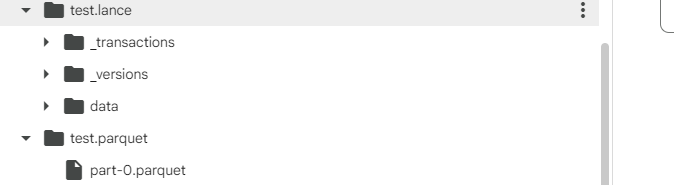

In [7]:
# lance 版本控制
# 将新数据附加到数据集
df = pd.DataFrame({"a": [10]})
tbl = pa.Table.from_pandas(df)
dataset = lance.write_dataset(tbl, "/tmp/test.lance", mode="append")
dataset.to_table().to_pandas()

,a,b
0,5,1
1,1,2
2,2,3
3,10,None


In [8]:
# 覆盖你的数据集
df = pd.DataFrame({"a": [50, 100]})
tbl = pa.Table.from_pandas(df)
dataset = lance.write_dataset(tbl, "/tmp/test.lance", mode="overwrite")
dataset.to_table().to_pandas()

,a
0,50
1,100


In [ ]:
# 访问先前的数据集版本

In [9]:
dataset.versions()

[{'version': 1,
  'timestamp': datetime.datetime(2025, 10, 22, 13, 41, 43, 166390),
  'metadata': {'total_data_file_rows': '3',
   'total_data_files': '1',
   'total_deletion_file_rows': '0',
   'total_deletion_files': '0',
   'total_files_size': '1127',
   'total_fragments': '1',
   'total_rows': '3'}},
 {'version': 2,
  'timestamp': datetime.datetime(2025, 10, 22, 13, 41, 46, 629522),
  'metadata': {'total_data_file_rows': '4',
   'total_data_files': '2',
   'total_deletion_file_rows': '0',
   'total_deletion_files': '0',
   'total_files_size': '1947',
   'total_fragments': '2',
   'total_rows': '4'}},
 {'version': 3,
  'timestamp': datetime.datetime(2025, 10, 22, 13, 41, 50, 303527),
  'metadata': {'total_data_file_rows': '2',
   'total_data_files': '1',
   'total_deletion_file_rows': '0',
   'total_deletion_files': '0',
   'total_files_size': '718',
   'total_fragments': '1',
   'total_rows': '2'}}]

In [10]:
# 通过版本访问数据
# version1
lance.dataset('/tmp/test.lance', version=1).to_table().to_pandas()

,a,b
0,5,1
1,1,2
2,2,3


In [11]:
# version2
lance.dataset('/tmp/test.lance', version=2).to_table().to_pandas()


,a,b
0,5,1
1,1,2
2,2,3
3,10,None


为你的版本打上标签

In [12]:
dataset.tags.create("stable", 2)
dataset.tags.create("nightly", 3)
dataset.tags.list()

{'nightly': {'version': 3, 'manifest_size': 660},
 'stable': {'version': 2, 'manifest_size': 880}}

In [13]:
lance.dataset('/tmp/test.lance', version="stable").to_table().to_pandas()

,a,b
0,5,1
1,1,2
2,2,3
3,10,None


3. 矢量搜索

In [14]:
import shutil
import lance
import numpy as np
import pandas as pd
import pyarrow as pa
import duckdb

In [15]:
# 准备向量嵌入
!rm -rf sift* vec_data.lance
!wget ftp://ftp.irisa.fr/local/texmex/corpus/sift.tar.gz
!tar -xzf sift.tar.gz


--2025-10-22 13:42:19--  ftp://ftp.irisa.fr/local/texmex/corpus/sift.tar.gz
           => ‘sift.tar.gz’
Resolving ftp.irisa.fr (ftp.irisa.fr)... 131.254.254.45, 2001:660:7303:254::45
Connecting to ftp.irisa.fr (ftp.irisa.fr)|131.254.254.45|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /local/texmex/corpus ... done.
==> SIZE sift.tar.gz ... 168280445
==> PASV ... done.    ==> RETR sift.tar.gz ... done.
Length: 168280445 (160M) (unauthoritative)

sift.tar.gz         100%[===================>] 160.48M  22.8MB/s    in 7.2s    

2025-10-22 13:42:27 (22.3 MB/s) - ‘sift.tar.gz’ saved [168280445]



In [16]:
# 将原始矢量数据转换为 Lance 格式，以便高效存储和查询。
from lance.vector import vec_to_table
import struct

uri = "vec_data.lance"

with open("sift/sift_base.fvecs", mode="rb") as fobj:
    buf = fobj.read()
    data = np.array(struct.unpack("<128000000f", buf[4 : 4 + 4 * 1000000 * 128])).reshape((1000000, 128))
    dd = dict(zip(range(1000000), data))

table = vec_to_table(dd)
lance.write_dataset(table, uri, max_rows_per_group=8192, max_rows_per_file=1024*1024)

In [17]:
# 现在您可以加载数据集
uri = "vec_data.lance"
sift1m = lance.dataset(uri)

In [18]:
sift1m.versions()

[{'version': 1,
  'timestamp': datetime.datetime(2025, 10, 22, 13, 42, 57, 276652),
  'metadata': {'total_data_file_rows': '1000000',
   'total_data_files': '1',
   'total_deletion_file_rows': '0',
   'total_deletion_files': '0',
   'total_files_size': '520001683',
   'total_fragments': '1',
   'total_rows': '1000000'}}]

In [19]:
# 先执行一个没有索引的向搜索，以便后续跟索引搜索做比较
import duckdb
# Make sure DuckDB v0.7+ is installed
samples = duckdb.query("SELECT vector FROM sift1m USING SAMPLE 100").to_df().vector
samples

,vector
0,"[0.0, 31.0, 82.0, 23.0, 50.0, 27.0, 0.0, 0.0, ..."
1,"[66.0, 124.0, 78.0, 5.0, 0.0, 0.0, 105.0, 11.0..."
2,"[35.0, 23.0, 6.0, 42.0, 24.0, 8.0, 20.0, 8.0, ..."
3,"[21.0, 5.0, 8.0, 23.0, 1.0, 128.0, 128.0, 110...."
4,"[0.0, 0.0, 5.0, 25.0, 10.0, 11.0, 54.0, 0.0, 0..."
...,...
95,"[0.0, 0.0, 66.0, 78.0, 26.0, 45.0, 3.0, 2.0, 3..."
96,"[33.0, 35.0, 10.0, 9.0, 5.0, 20.0, 11.0, 24.0,..."
97,"[65.0, 90.0, 0.0, 0.0, 0.0, 0.0, 11.0, 62.0, 1..."
98,"[0.0, 0.0, 51.0, 122.0, 122.0, 27.0, 9.0, 0.0,..."


In [20]:
samples.shape

(100,)

In [21]:
# 现在，执行不使用索引的最近邻搜索。
# 如果没有索引，搜索将扫描整个数据集来计算每个数据点之间的距离。
# 为了获得实际的实时性能，使用 ANN 索引将获得更好的性能。

import time

start = time.time()
tbl = sift1m.to_table(columns=["id"], nearest={"column": "vector", "q": samples[0], "k": 10})
end = time.time()

print(f"Time(sec): {end-start}")
print(tbl.to_pandas())

Time(sec): 0.46197080612182617
       id  _distance
0  157294        0.0
1  985603    83468.0
2  311062    85113.0
3  365500    93181.0
4  630853    94298.0
5  437611    97023.0
6  218827    97218.0
7   53449    98152.0
8  658588    98939.0
9  420712   103528.0


In [22]:
# 构建ANN索引，可以显著加速向量搜索的速度，同时保证较高的准确率
sift1m.create_index(
    "vector",
    index_type="IVF_PQ", # specify the IVF_PQ index type
    num_partitions=256,  # IVF
    num_sub_vectors=16,  # PQ
)

INFO:pylance:Final create_index rust time: 222.85590744018555s


这段代码的作用是为`sift1m`数据集（通常是包含100万条SIFT特征向量的数据集）中的`vector`字段构建一个ANN（Approximate Nearest Neighbor，近似最近邻）索引，具体使用的是`IVF_PQ`索引类型，目的是在保证较高准确率的同时，显著加速向量搜索的速度。


### 代码参数解释：
1. **`"vector"`**  
   指定要为数据集中的哪个字段构建索引，这里是名为`vector`的字段（存储的是需要进行相似度搜索的向量数据，比如SIFT特征向量）。


2. **`index_type="IVF_PQ"`**  
   指定索引类型为`IVF_PQ`，这是一种结合了IVF（Inverted File，倒排文件）和PQ（Product Quantization，乘积量化）的混合索引方法，是工业界常用的高效向量索引方案：
   - **IVF（倒排文件）**：先将向量空间划分为多个聚类（分区），搜索时先找到目标向量所属的几个候选分区，再在这些分区内进行精细搜索，减少需比较的向量数量。
   - **PQ（乘积量化）**：将高维向量拆分为多个低维子向量，对每个子向量进行量化（用有限的“码本”表示），从而大幅压缩向量存储空间，加速距离计算。


3. **`num_partitions=256`**  
   这是IVF的核心参数，指定将向量空间划分为256个分区（聚类中心）。  
   - 分区数量越多，每个分区内的向量越集中，搜索时需遍历的向量越少，速度越快；但分区过多可能导致聚类中心不准确，影响搜索准确率。


4. **`num_sub_vectors=16`**  
   这是PQ的核心参数，指定将原始高维向量拆分为16个低维子向量。  
   - 例如，若原始SIFT向量是128维，拆分后每个子向量为8维（128/16=8），然后对每个8维子向量单独量化。  
   - 子向量数量越多，量化损失越小，准确率越高，但存储和计算成本会略有增加（需权衡速度和准确率）。


### 总结：
通过构建`IVF_PQ`索引，后续对`sift1m`数据集的向量搜索（如找与目标向量最相似的向量）会先通过IVF快速定位候选分区，再通过PQ加速分区内的距离计算，从而在近似结果中大幅提升搜索效率，同时保持较高的准确率（相比暴力搜索，速度提升通常在10-100倍以上）。

In [23]:
# 这里我们再通过索引执行上面的操作
sift1m = lance.dataset(uri)

import time

tot = 0
for q in samples:
    start = time.time()
    tbl = sift1m.to_table(nearest={"column": "vector", "q": q, "k": 10})
    end = time.time()
    tot += (end - start)

print(f"Avg(sec): {tot / len(samples)}")
print(tbl.to_pandas())

Avg(sec): 0.00570380449295044
       id                                             vector      _distance
0  924903  [0.0, 0.0, 42.0, 74.0, 40.0, 36.0, 0.0, 0.0, 0...   28975.839844
1  369429  [0.0, 14.0, 37.0, 42.0, 40.0, 33.0, 0.0, 0.0, ...   83802.578125
2  945930  [5.0, 46.0, 74.0, 23.0, 31.0, 54.0, 7.0, 1.0, ...  103174.539062
3  561179  [0.0, 0.0, 0.0, 7.0, 21.0, 5.0, 5.0, 15.0, 4.0...  106254.765625
4  208953  [0.0, 0.0, 0.0, 0.0, 4.0, 54.0, 29.0, 2.0, 9.0...  111853.812500
5  647504  [0.0, 6.0, 22.0, 2.0, 136.0, 124.0, 15.0, 0.0,...  112582.757812
6   64989  [0.0, 2.0, 30.0, 55.0, 44.0, 84.0, 0.0, 0.0, 2...  113234.078125
7  864015  [1.0, 10.0, 103.0, 84.0, 14.0, 117.0, 15.0, 0....  115253.367188
8  160449  [8.0, 22.0, 1.0, 9.0, 16.0, 41.0, 0.0, 0.0, 3....  115763.671875
9  469920  [7.0, 12.0, 105.0, 44.0, 41.0, 17.0, 23.0, 1.0...  116065.687500


您需要调整搜索参数以在速度和准确性之间取得平衡，找到适合您用例的最佳设置。


延迟与召回率可通过以下方式调整：
- nprobes ：要搜索多少个 IVF 分区
- refine_factor ：确定在重新排序期间检索到多少个向量


In [24]:
%%time

sift1m.to_table(
    nearest={
        "column": "vector",
        "q": samples[0],
        "k": 10,
        "nprobes": 10,
        "refine_factor": 5,
    }
).to_pandas()

# 参数解释：
# - q => 样本向量
# - k => 返回多少个邻居
# - nprobes => 探测多少个分区（在粗量化器中）
# - refine_factor => 控制“重新排序”。
# 如果 k=10 且 refine_factor=5，则通过 ANN 检索 50 个最近邻居
# 并使用实际距离重新排序，然后返回前 10 个。这可以在不牺牲太多性能的情况下提高召回率。


CPU times: user 10.3 ms, sys: 52 µs, total: 10.3 ms
Wall time: 11.4 ms


,id,vector,_distance
0,157294,"[0.0, 31.0, 82.0, 23.0, 50.0, 27.0, 0.0, 0.0, ...",0.0
1,985603,"[13.0, 44.0, 77.0, 24.0, 80.0, 47.0, 13.0, 0.0...",83468.0
2,311062,"[0.0, 17.0, 128.0, 8.0, 3.0, 8.0, 0.0, 0.0, 18...",85113.0
3,365500,"[1.0, 44.0, 103.0, 82.0, 48.0, 4.0, 7.0, 11.0,...",93181.0
4,630853,"[10.0, 45.0, 89.0, 15.0, 7.0, 3.0, 2.0, 5.0, 1...",94298.0
5,437611,"[0.0, 34.0, 119.0, 36.0, 18.0, 24.0, 24.0, 16....",97023.0
6,218827,"[12.0, 6.0, 117.0, 35.0, 94.0, 32.0, 13.0, 0.0...",97218.0
7,53449,"[0.0, 32.0, 127.0, 55.0, 23.0, 0.0, 0.0, 0.0, ...",98152.0
8,658588,"[0.0, 40.0, 30.0, 35.0, 76.0, 12.0, 0.0, 0.0, ...",98939.0
9,420712,"[0.0, 10.0, 68.0, 83.0, 50.0, 23.0, 2.0, 0.0, ...",103528.0


您可以将元数据列添加到矢量数据集，并在单个操作中同时查询矢量和特征。

在实际情况下，用户需要将其他特性或元数据列一起存储和获取。

如果您分别管理数据和索引，则必须进行大量繁琐的管道操作才能将它们整合在一起。

使用 Lance，您可以使用 add_columns() 直接向数据集添加列

In [25]:
sift1m.add_columns(
    {
        "item_id": "id + 1000000",
        "revenue": "random() * 1000 + 5000",
    }
)

In [26]:
sift1m.versions()

[{'version': 1,
  'timestamp': datetime.datetime(2025, 10, 22, 13, 42, 57, 276652),
  'metadata': {'total_data_file_rows': '1000000',
   'total_data_files': '1',
   'total_deletion_file_rows': '0',
   'total_deletion_files': '0',
   'total_files_size': '520001683',
   'total_fragments': '1',
   'total_rows': '1000000'}},
 {'version': 2,
  'timestamp': datetime.datetime(2025, 10, 22, 13, 47, 15, 172172),
  'metadata': {'total_data_file_rows': '1000000',
   'total_data_files': '1',
   'total_deletion_file_rows': '0',
   'total_deletion_files': '0',
   'total_files_size': '520001683',
   'total_fragments': '1',
   'total_rows': '1000000'}},
 {'version': 3,
  'timestamp': datetime.datetime(2025, 10, 22, 13, 54, 26, 60020),
  'metadata': {'total_data_file_rows': '1000000',
   'total_data_files': '2',
   'total_deletion_file_rows': '0',
   'total_deletion_files': '0',
   'total_files_size': '536002089',
   'total_fragments': '1',
   'total_rows': '1000000'}}]

In [27]:
@lance.batch_udf()
def add_columns_func(batch: pa.Table) -> pd.DataFrame:
    """Add item_id and revenue columns to a batch of data.

    Args:
        batch: PyArrow Table containing the original data

    Returns:
        Pandas DataFrame with added item_id and revenue columns
    """
    item_ids: np.ndarray = np.arange(batch.num_rows)
    revenue: np.ndarray = (np.random.randn(batch.num_rows) + 5) * 1000
    return pd.DataFrame({"item_id1": item_ids, "revenue1": revenue})


sift1m.add_columns(add_columns_func)

In [28]:
sift1m.versions()

[{'version': 1,
  'timestamp': datetime.datetime(2025, 10, 22, 13, 42, 57, 276652),
  'metadata': {'total_data_file_rows': '1000000',
   'total_data_files': '1',
   'total_deletion_file_rows': '0',
   'total_deletion_files': '0',
   'total_files_size': '520001683',
   'total_fragments': '1',
   'total_rows': '1000000'}},
 {'version': 2,
  'timestamp': datetime.datetime(2025, 10, 22, 13, 47, 15, 172172),
  'metadata': {'total_data_file_rows': '1000000',
   'total_data_files': '1',
   'total_deletion_file_rows': '0',
   'total_deletion_files': '0',
   'total_files_size': '520001683',
   'total_fragments': '1',
   'total_rows': '1000000'}},
 {'version': 3,
  'timestamp': datetime.datetime(2025, 10, 22, 13, 54, 26, 60020),
  'metadata': {'total_data_file_rows': '1000000',
   'total_data_files': '2',
   'total_deletion_file_rows': '0',
   'total_deletion_files': '0',
   'total_files_size': '536002089',
   'total_fragments': '1',
   'total_rows': '1000000'}},
 {'version': 4,
  'timestamp': d

In [32]:
%%time
# 然后，您可以同时查询向量和元数据：
# Get vectors and metadata together
result = sift1m.to_table(
    columns=["item_id", "revenue","item_id1", "revenue1"],
    nearest={"column": "vector", "q": samples[0], "k": 10}
)
print(result.to_pandas())

   item_id      revenue  item_id1     revenue1     _distance
0  1157294  5011.273400       622  6380.441552  18216.443359
1  1420712  5233.960723       872  3468.894868  85457.515625
2  1985603  5695.484891       515  5541.645735  86977.148438
3  1311062  5069.853157       790  7043.024883  89125.132812
4  1218827  5303.647234       715  5624.905240  90611.421875
5  1678196  5329.608702       308  5146.601096  92014.812500
6  1543391  5427.075609       671  4431.306609  93281.601562
7  1303193  5727.261222        89  5461.930550  94284.265625
8  1365500  5040.159537       956  4666.646295  95132.835938
9  1369886  5022.507554       222  6461.976678  95280.429688
CPU times: user 10.5 ms, sys: 3.95 ms, total: 14.5 ms
Wall time: 14.3 ms
